# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,L0_Na,psi_NE_I,psi_NE_H,psi_NE_P,L0_NE,psi_EM_I,psi_EM_H,psi_EM_P,L0_EM,psi_EE_I,psi_EE_H,psi_EE_P,L0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
20,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.605170,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
150,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-2.302585,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
280,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
410,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,2.302585,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
540,0.0,0.01,100000000.0,0.0,10000000.0,30.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,-4.60517,0.0,0.0,0.0,4.605170,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.0,0.0,20.0000,20.0000,0.094332,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40380629,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,-4.605170,5.302966e+06,745.206312,1.992333,1.794133,4.534481,0.0,20.0,20.0000,-6.8880,0.027191,1.122813,0.000508,6.028153e+06,3.349485,2.651569,0.000086,0.000373
40380759,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,-2.302585,5.302938e+06,878.007541,2.173267,1.940267,4.533714,0.0,20.0,20.0000,-2.7856,0.027191,1.122809,0.000598,6.028179e+06,3.349485,2.651569,0.000100,0.000439
40380889,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,0.000000,5.302296e+06,3574.598859,3.935533,2.976600,4.222655,0.0,20.0,20.0000,-8.6832,0.027186,1.122710,0.002429,6.028769e+06,3.349485,2.651569,0.000421,0.001787
40381019,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,4.60517,0.0,0.0,0.0,2.302585,5.281215e+06,80956.168445,52.451733,3.689867,1.675535,0.0,20.0,4.5040,-11.2800,0.027015,1.119414,0.223366,6.048124e+06,3.349485,2.651569,0.010961,0.040478


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag. ind.", "Harm ind.", "Tox. ind.", "Threshold"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

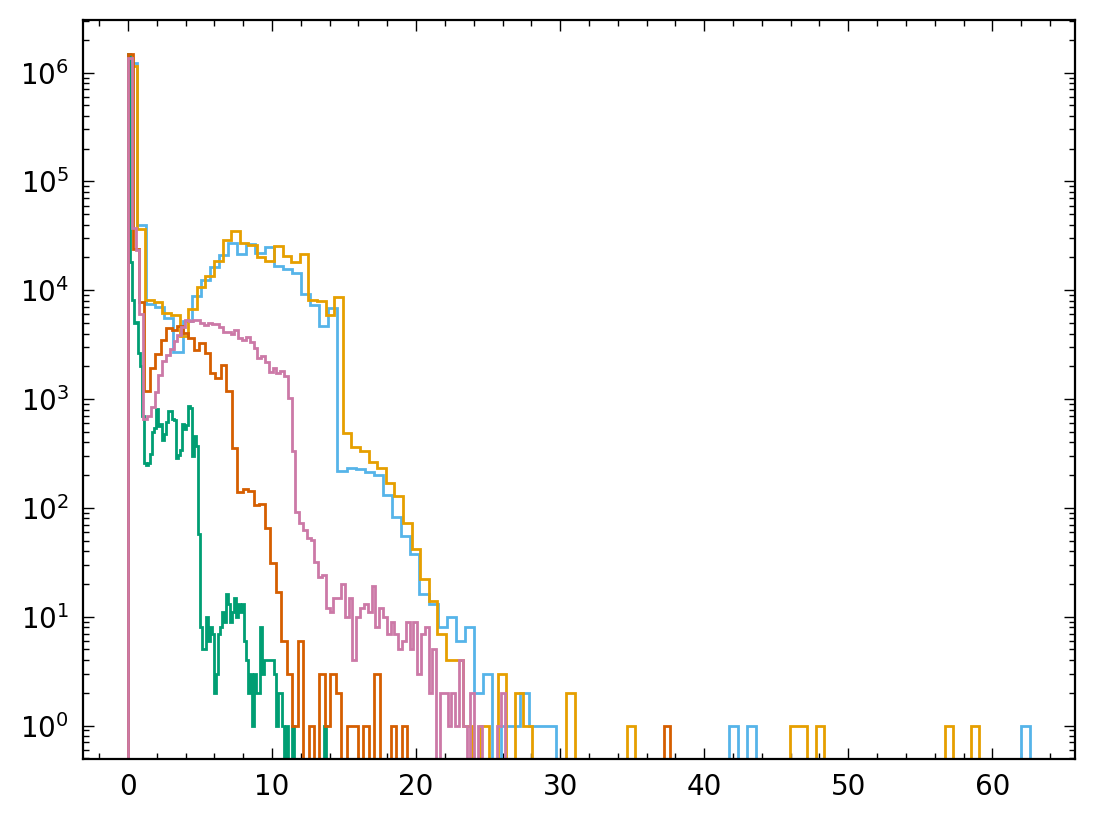

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,-26.795884,1.681079,1.062088,0.642149
1,-6.698971,3.226376,1.064944,0.745021
2,0.700124,0.205051,1.143228,0.133791
3,0.717337,0.276010,1.329414,0.182041
4,0.735609,0.339746,1.450676,0.228037
...,...,...,...,...
100,2.677607,4.728744,1.643943,0.491313
101,2.813581,5.044572,1.656256,0.523199
102,3.349485,0.027028,1.117504,0.126856
103,5.359177,0.141626,1.110082,0.175972


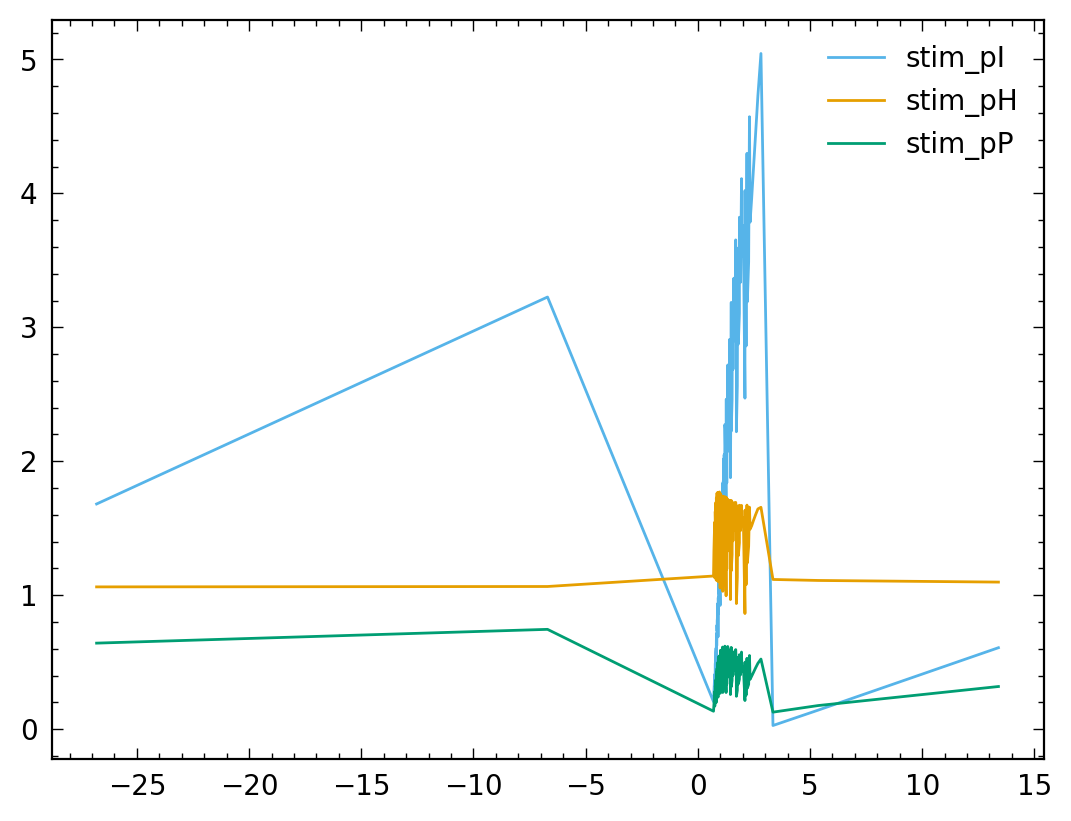

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 13
fevals: 14
fevals: 12
fevals: 13


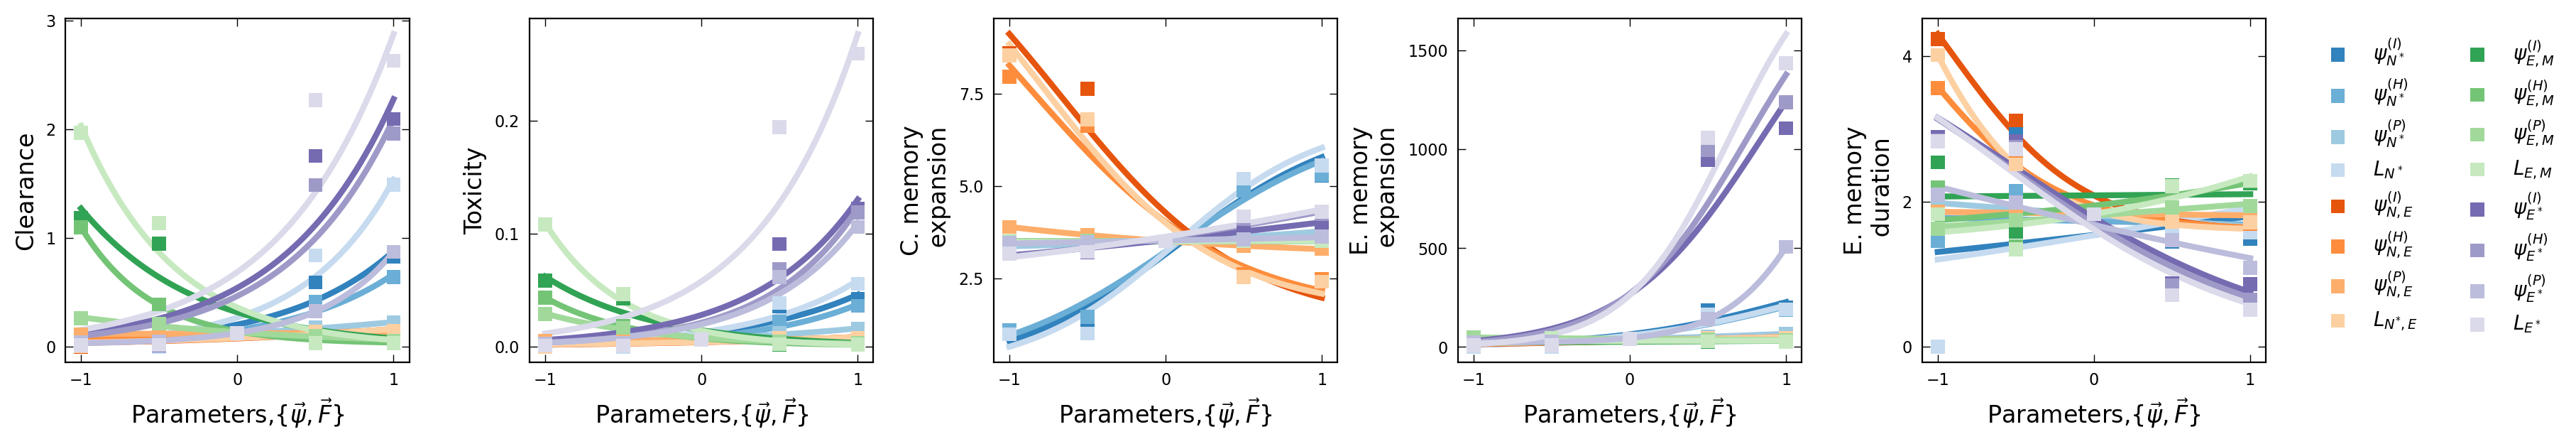

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules

fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    data = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[zero_regs]), axis = 1) == 0.0)]
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.loc[(np.sum(np.abs(data[reg_choice]), axis = 1) == np.abs(data[reg_choice[j]]))].groupby(reg_choice[j], as_index = False).mean()
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=5000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Parameters,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

        if i == 0:
            print("fevals:", infodict['nfev'])

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.35, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
# del data

fevals: 10
fevals: 10
fevals: 10
fevals: 10


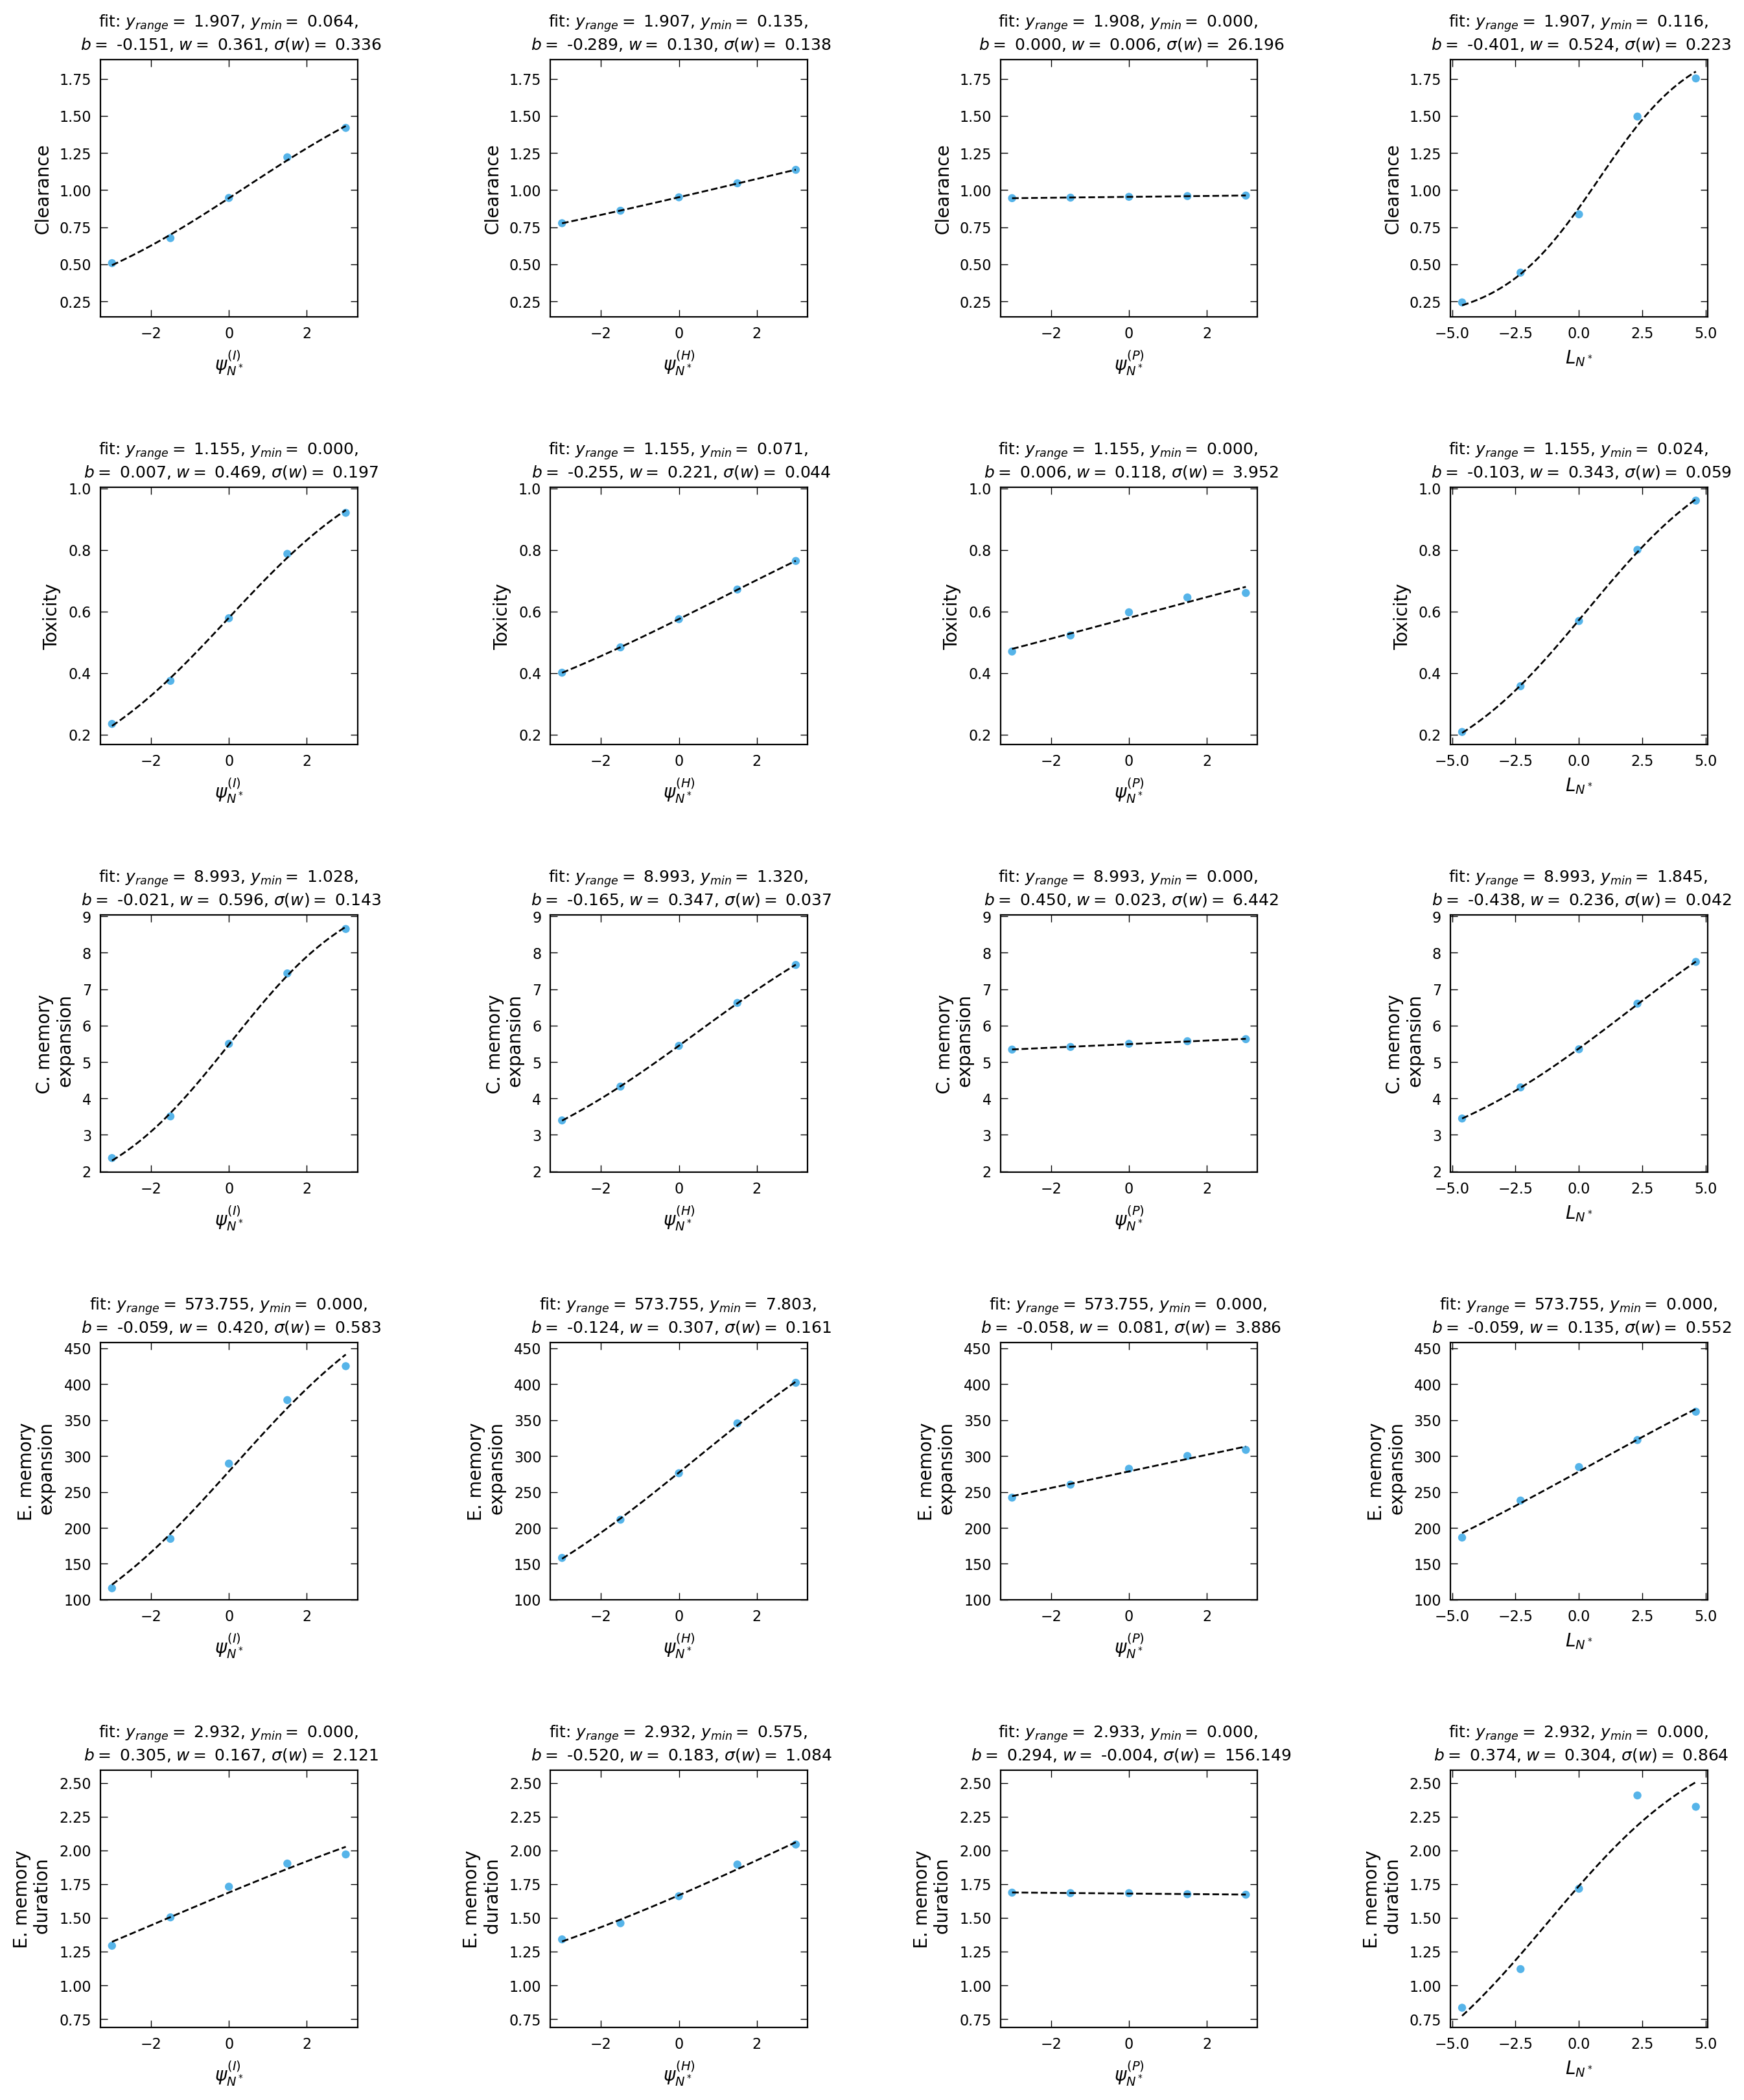

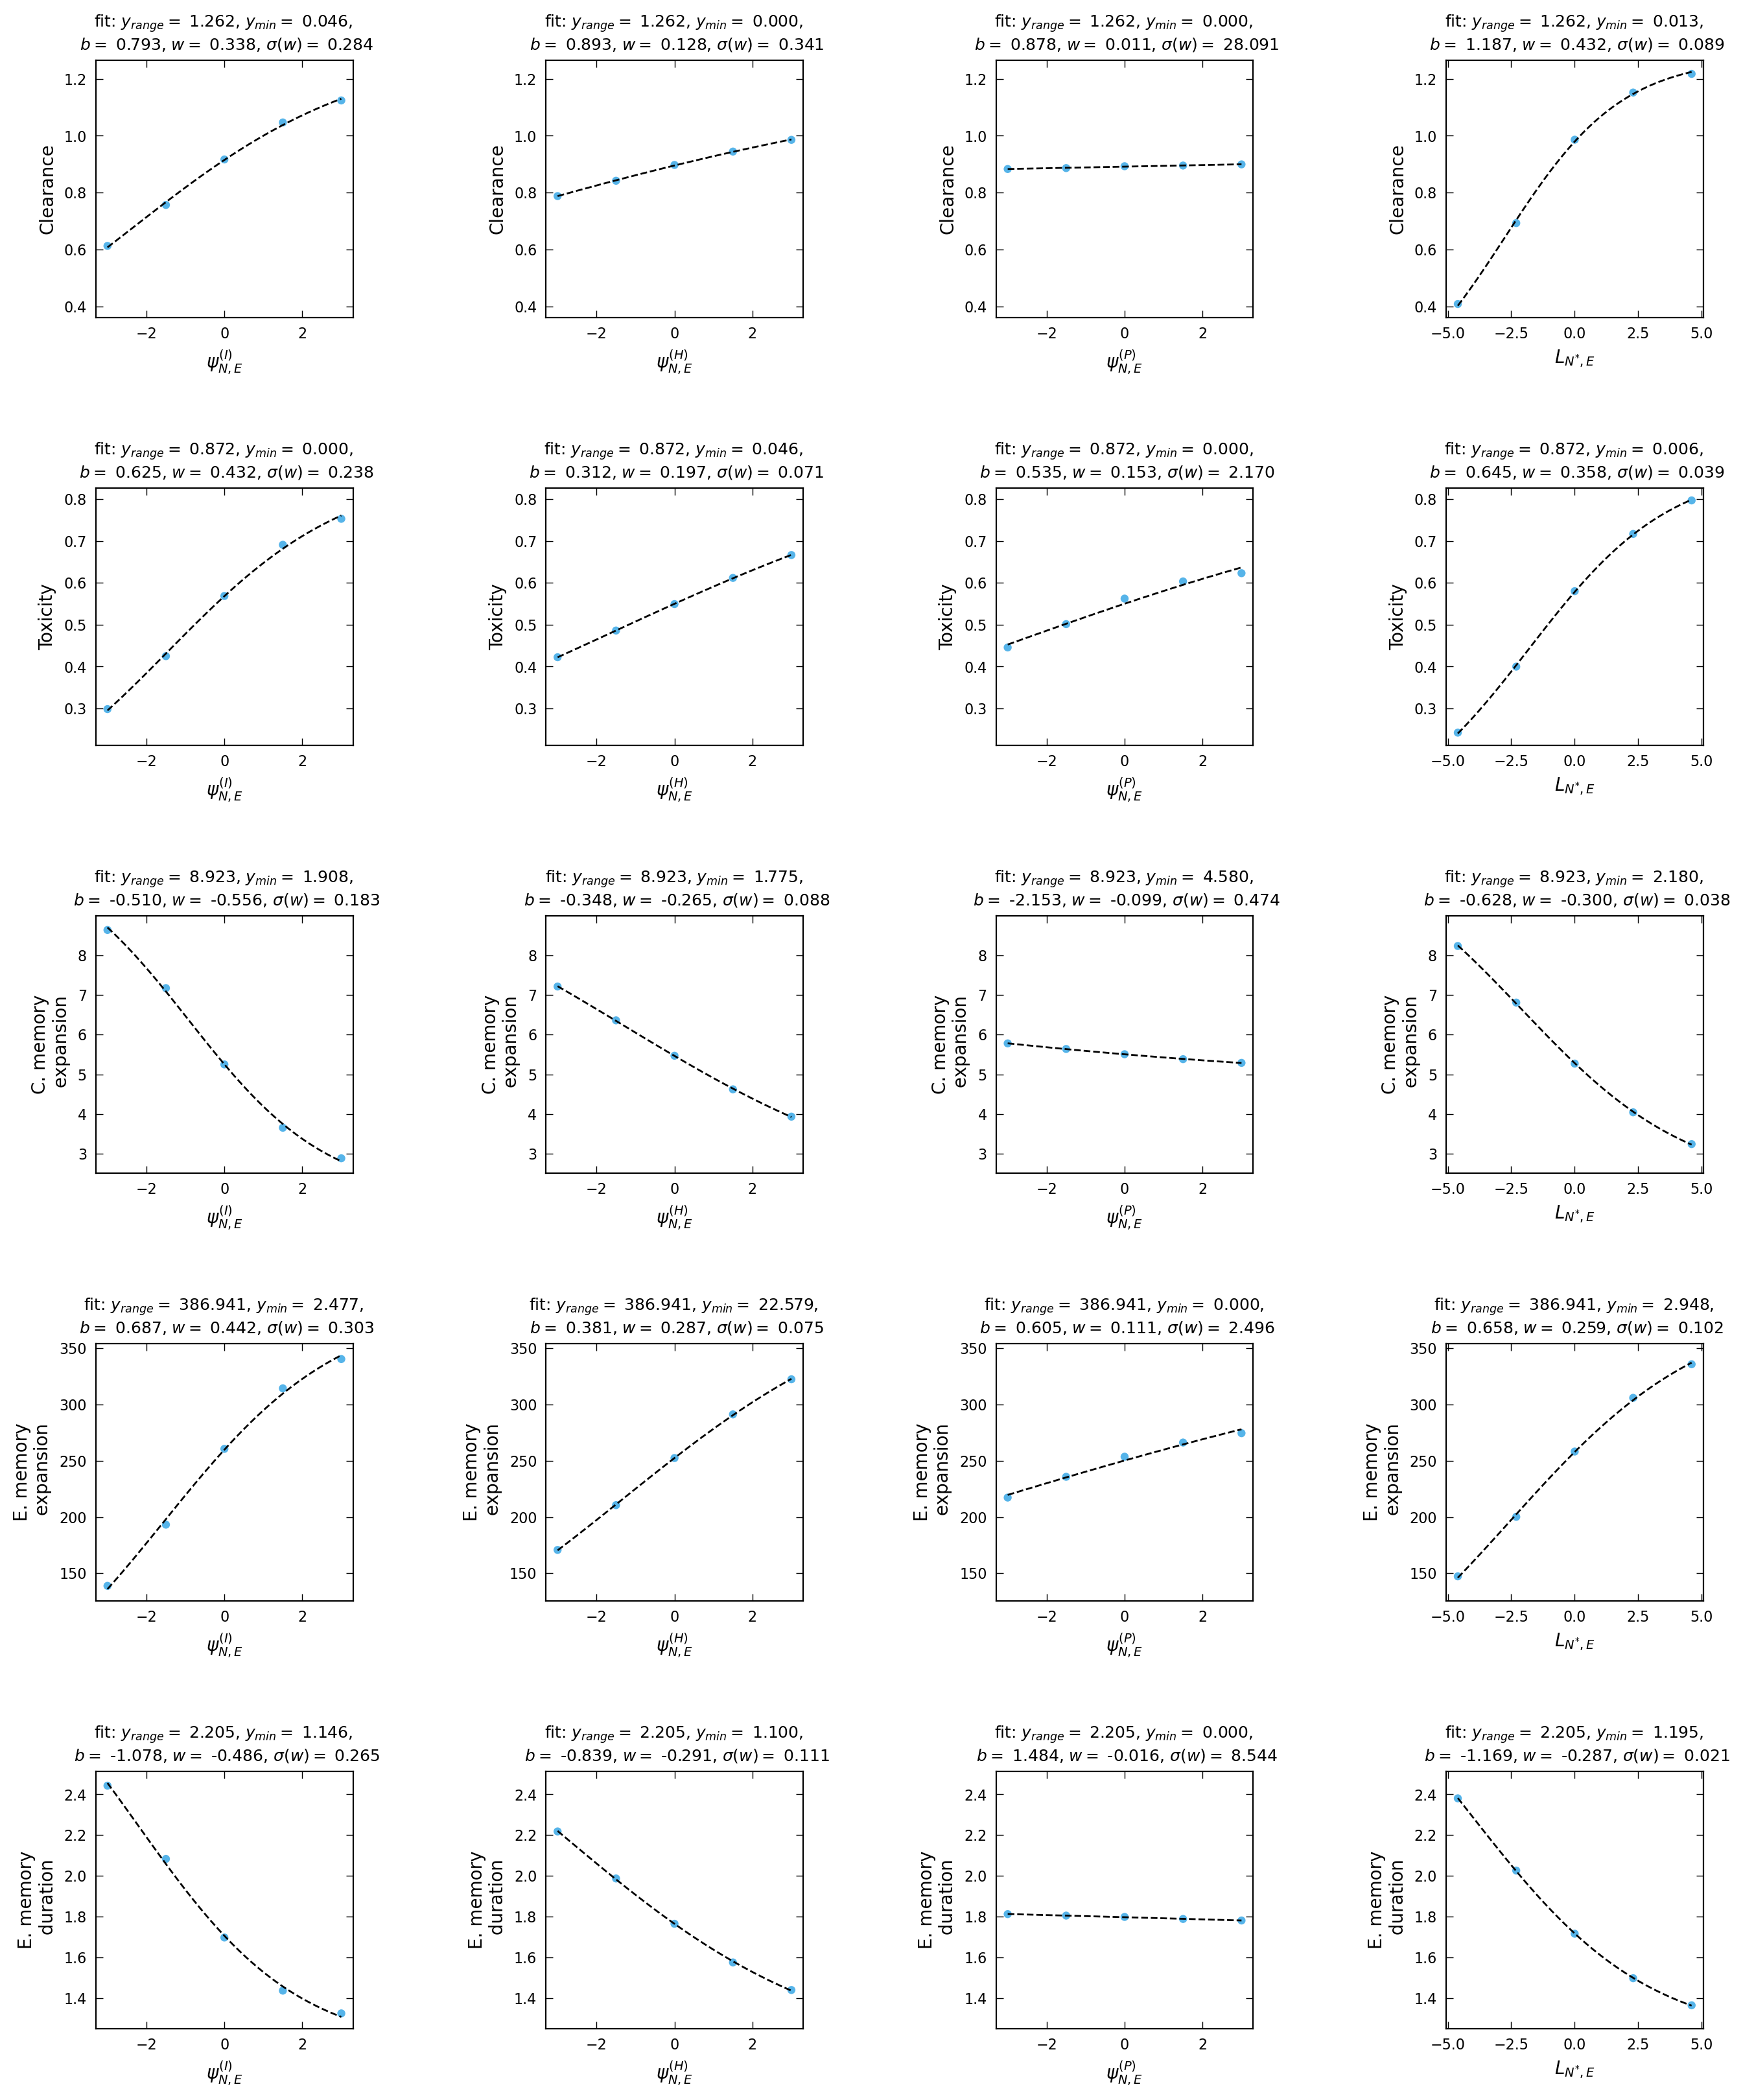

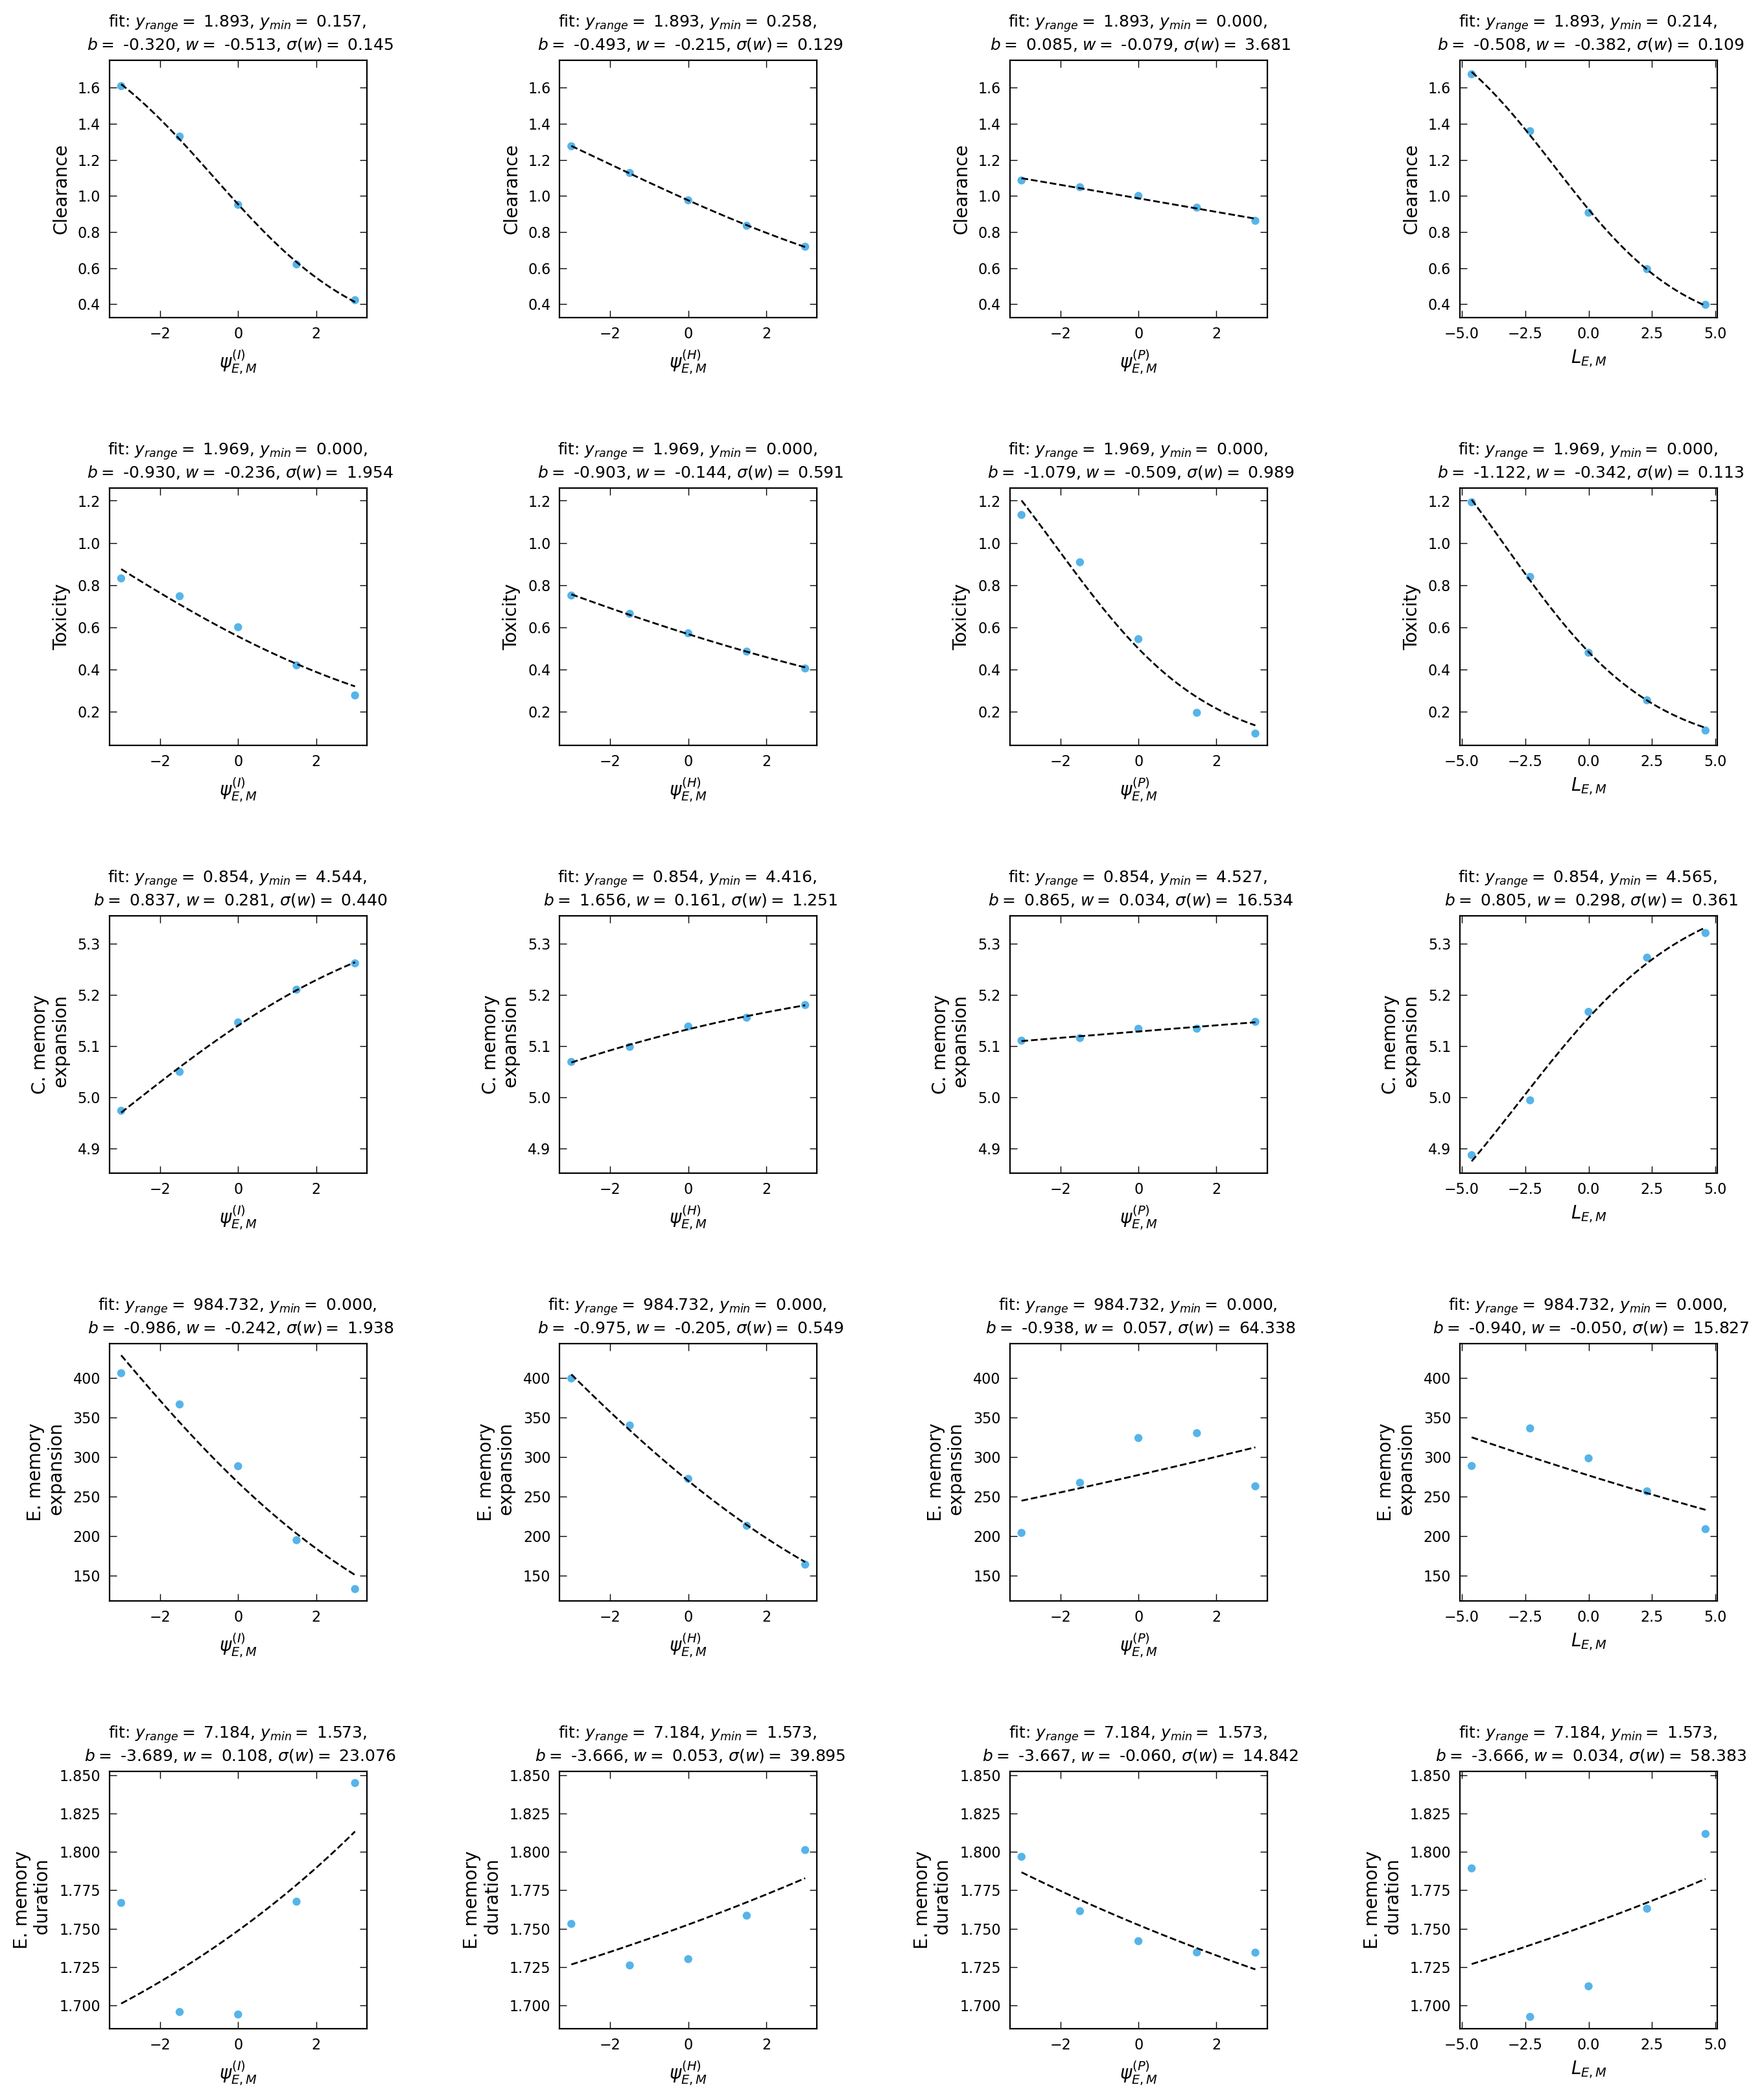

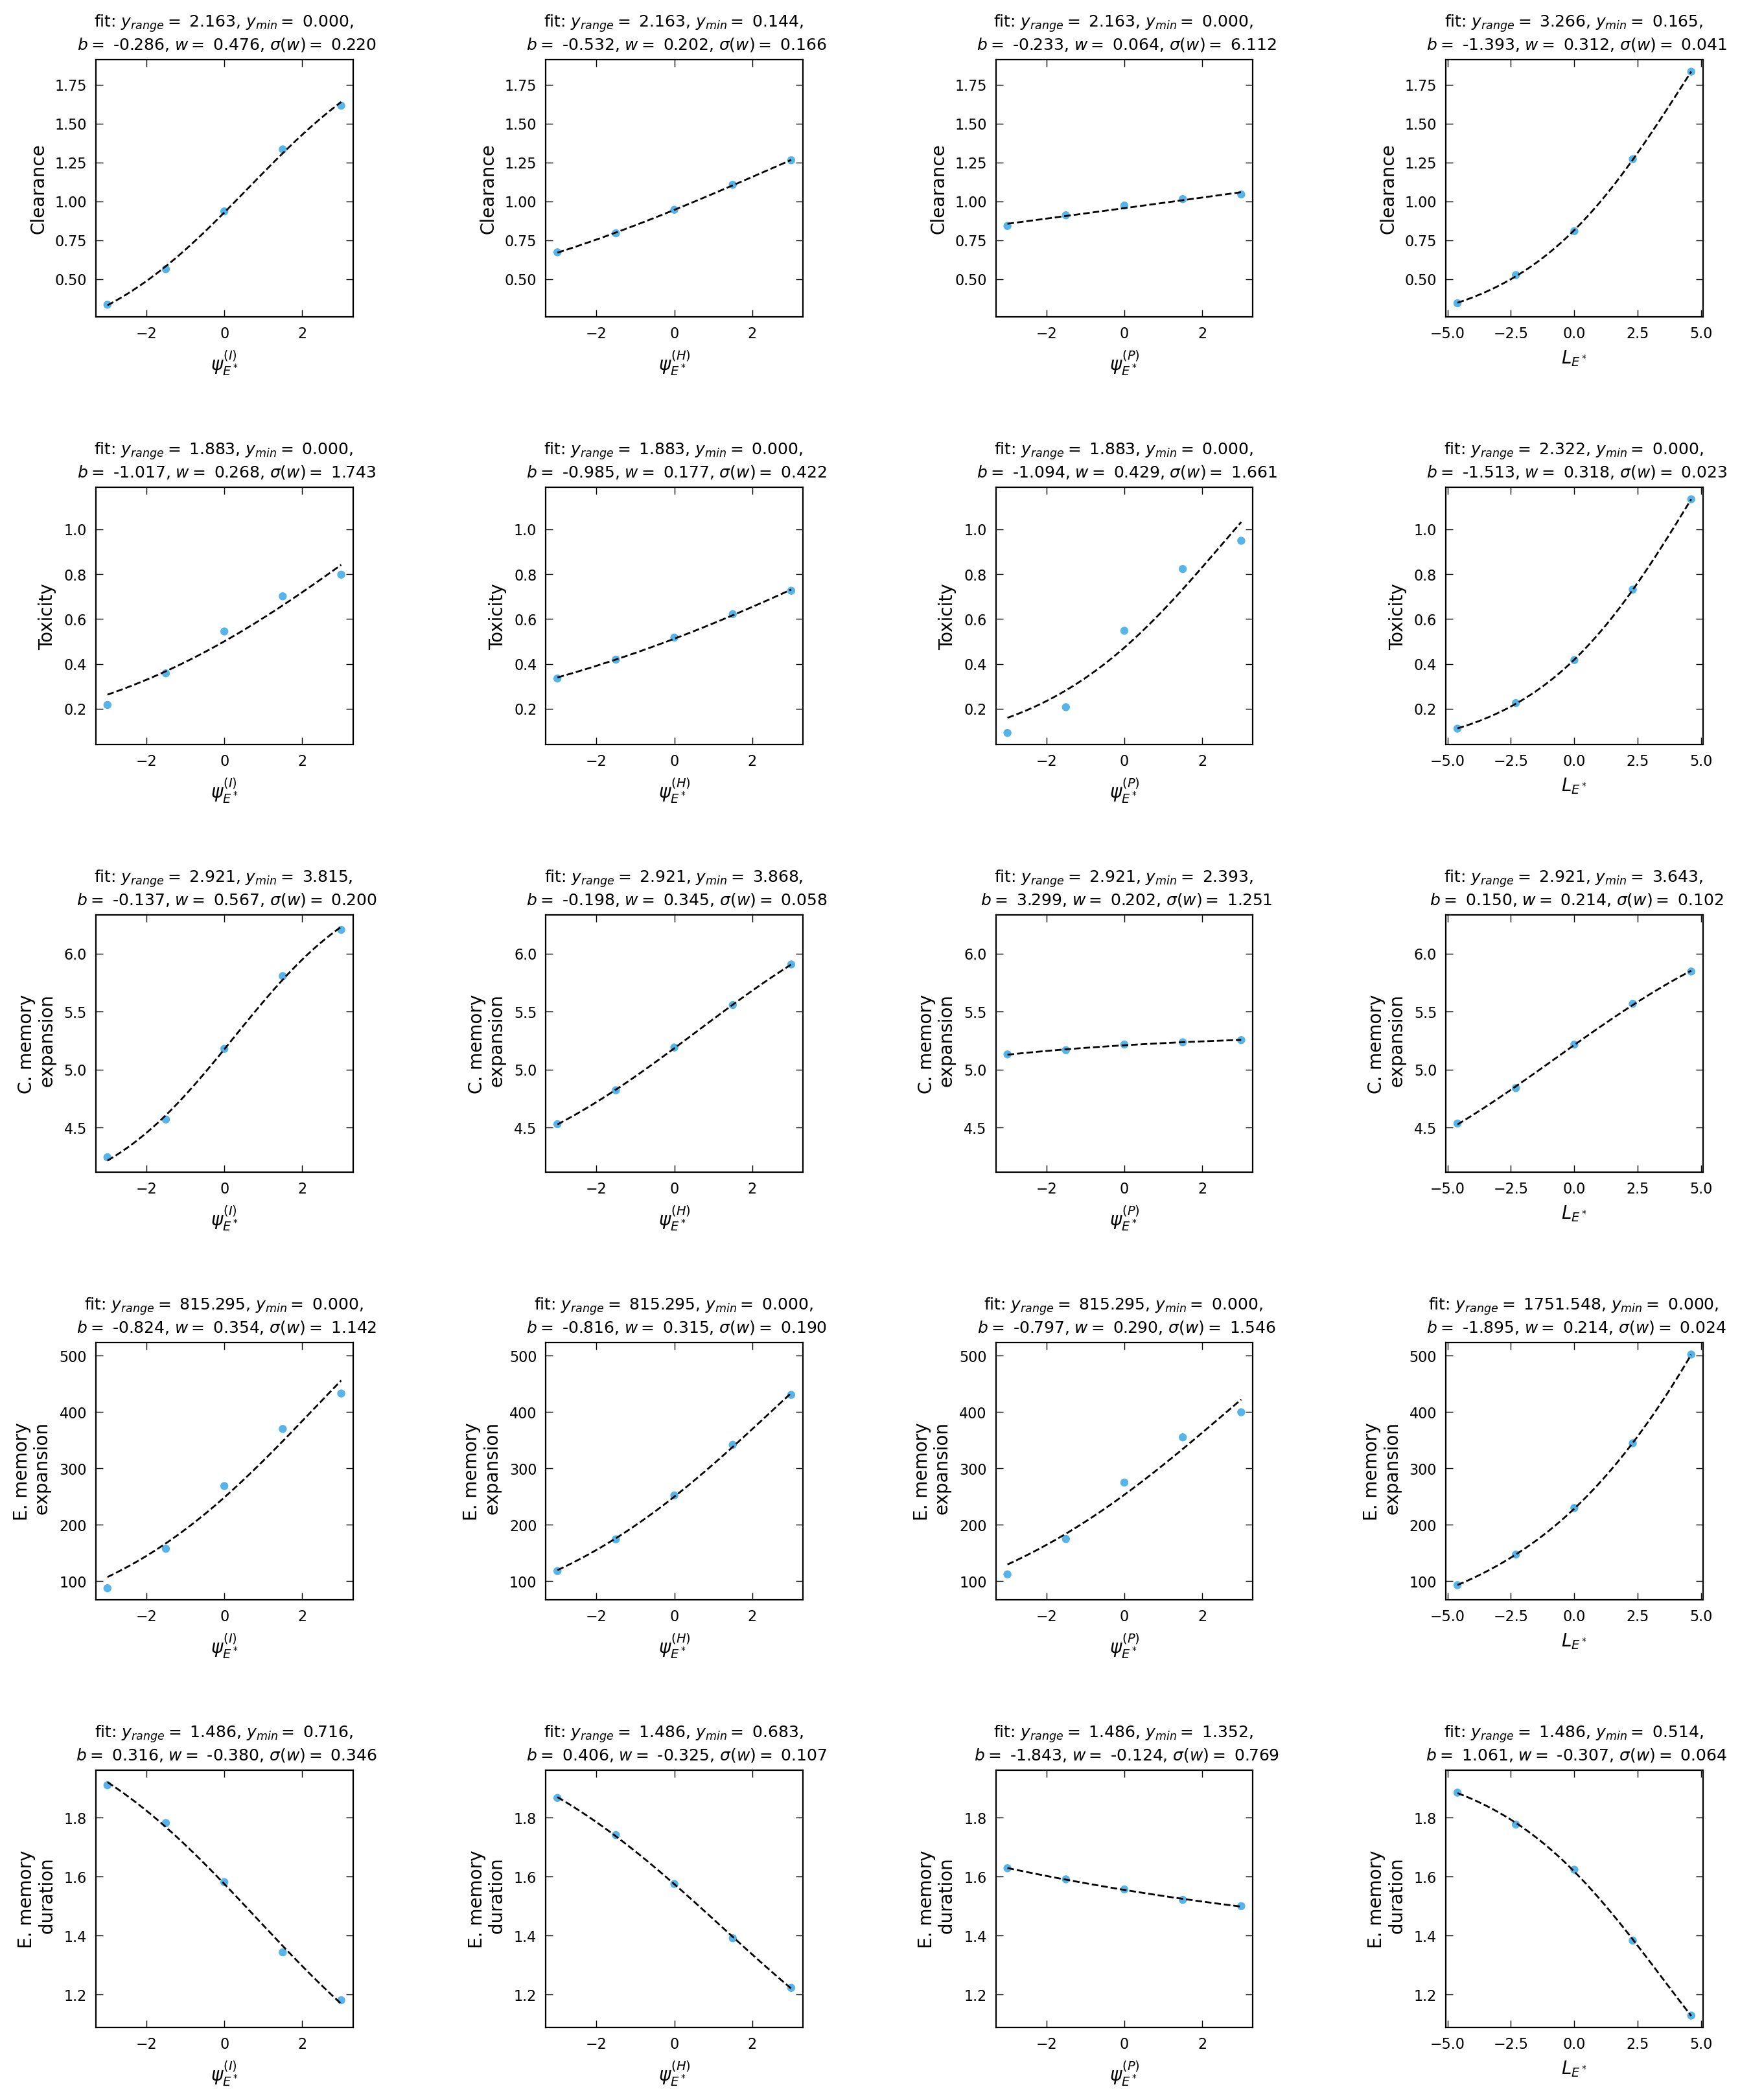

In [8]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [9]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [10]:
# Regress Performance measures on regulation parameters
num_cpu = 133
variables = reg

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min), 0.0 if y_min > 0.0 else y_min] + len(variables)*[-3.0*L0_max] + num_modules*[-3.0*L0_max], 
                                     [1.01*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[3.0*L0_max] + num_modules*[3.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [11]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [12]:
# View result
perf = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,L0_Na,psi_NE_I,psi_NE_H,psi_NE_P,L0_NE,psi_EM_I,psi_EM_H,psi_EM_P,L0_EM,psi_EE_I,psi_EE_H,psi_EE_P,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,0.429400,1.665724e-16,0.201838,0.027568,0.296313,4.195388,0.095743,0.164368,0.031312,0.943345,-0.101048,-0.025103,-0.250016,-1.612105,0.144350,0.059880,0.287567,1.865474,2.486703,1.372030,-3.397240,-7.097446,0.000615,0.000009,0.003370,0.003218,0.003403,0.153028,0.001071,0.001081,0.001066,0.001073,0.000888,0.000879,0.000929,0.002935,0.000971,0.000854,0.001421,0.003377,0.005634,0.002430,0.006385,0.008736,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.008683,0.429400,0.0,0.000000e+00,1.0,0.004709,0.043453,0.000000,0.094331,0.060789,0.030842,NaN
6,1.399968,1.027746e-04,0.194201,0.157933,0.477478,4.180742,0.087982,0.171330,0.085672,0.938712,-0.118894,-0.026725,-0.561555,-1.430176,0.123018,0.044817,0.611534,1.948740,2.562282,1.382981,-3.054538,-7.579033,0.001417,0.000034,0.003455,0.003400,0.003749,0.120600,0.001274,0.001289,0.001274,0.001286,0.001114,0.001095,0.001441,0.002301,0.000909,0.000893,0.001481,0.002917,0.007243,0.002934,0.004772,0.009612,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.027178,1.394696,0.0,0.000000e+00,1.0,0.017726,0.136732,0.000000,0.094329,0.060789,0.062536,NaN
11,4.508140,1.793632e-03,0.196433,0.237627,0.625323,4.153547,0.088976,0.172868,0.158040,0.940578,-0.129893,-0.034312,-0.965639,-1.365245,0.136696,0.051897,0.932983,2.058699,2.590850,1.379258,-3.036591,-8.162621,0.004642,0.000128,0.003780,0.003842,0.004399,0.090817,0.001575,0.001594,0.001590,0.001596,0.001270,0.001247,0.002387,0.002820,0.001128,0.001108,0.001954,0.003438,0.009133,0.003623,0.005855,0.012615,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.083877,4.463505,0.0,0.000000e+00,1.0,0.068016,0.427093,0.000000,0.094324,0.060789,0.117081,NaN
16,13.807000,6.140440e-03,0.207642,0.323364,0.806406,3.878283,0.090660,0.179447,0.249523,0.951033,-0.129945,-0.040384,-1.315791,-1.356869,0.161087,0.064938,1.209947,2.085192,2.701858,1.405793,-2.991969,-8.303499,0.014788,0.000446,0.004061,0.004227,0.005143,0.030414,0.001796,0.001820,0.001849,0.001829,0.001495,0.001468,0.003162,0.003032,0.001319,0.001289,0.002556,0.003828,0.011177,0.004140,0.006288,0.014676,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.259380,13.670297,0.0,3.201443e-07,1.0,0.236986,1.330137,0.000000,0.094308,0.060789,0.198065,NaN
21,40.515064,6.871128e-04,0.243267,0.407174,1.004273,3.827661,0.087614,0.179549,0.354391,0.930059,-0.101349,-0.038095,-1.701178,-1.397648,0.166532,0.082226,1.446978,1.890489,2.837123,1.392666,-3.025186,-7.363112,0.045687,0.001485,0.004430,0.004715,0.006204,0.020411,0.001959,0.001987,0.002083,0.001949,0.001726,0.001710,0.004799,0.003494,0.001551,0.001519,0.003107,0.003353,0.013431,0.004469,0.007286,0.012299,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.793152,40.113925,0.0,1.076958e-06,1.0,0.786505,4.052520,0.000000,0.094260,0.060789,0.310605,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,0.394957,1.653042e-40,0.298014,2.559359,0.175280,2.487534,0.095465,0.943380,0.107181,0.934883,-0.142036,-1.461542,-0.300521,-1.360993,0.174089,1.842046,0.275780,1.665477,0.785901,1.344005,-2.878108,-5.904996,0.000254,0.000009,0.002297,0.007450,0.0

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

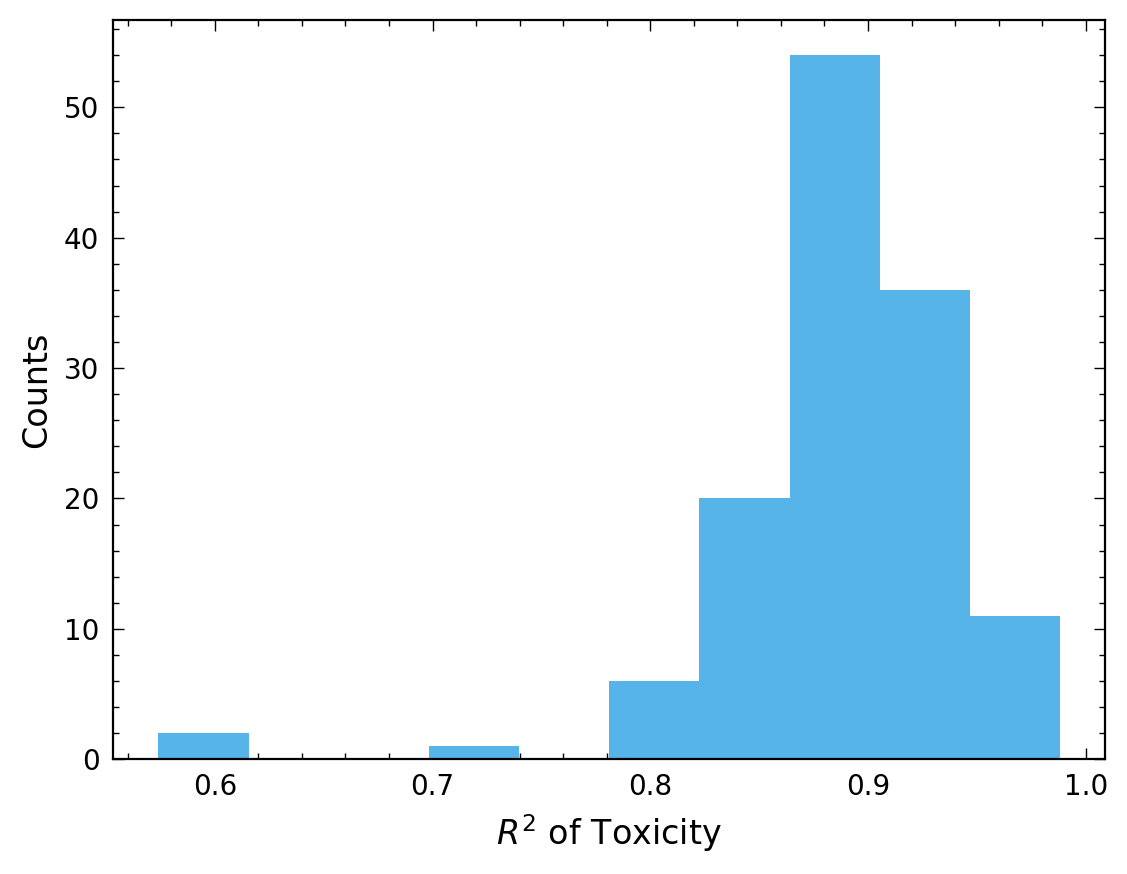

In [13]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

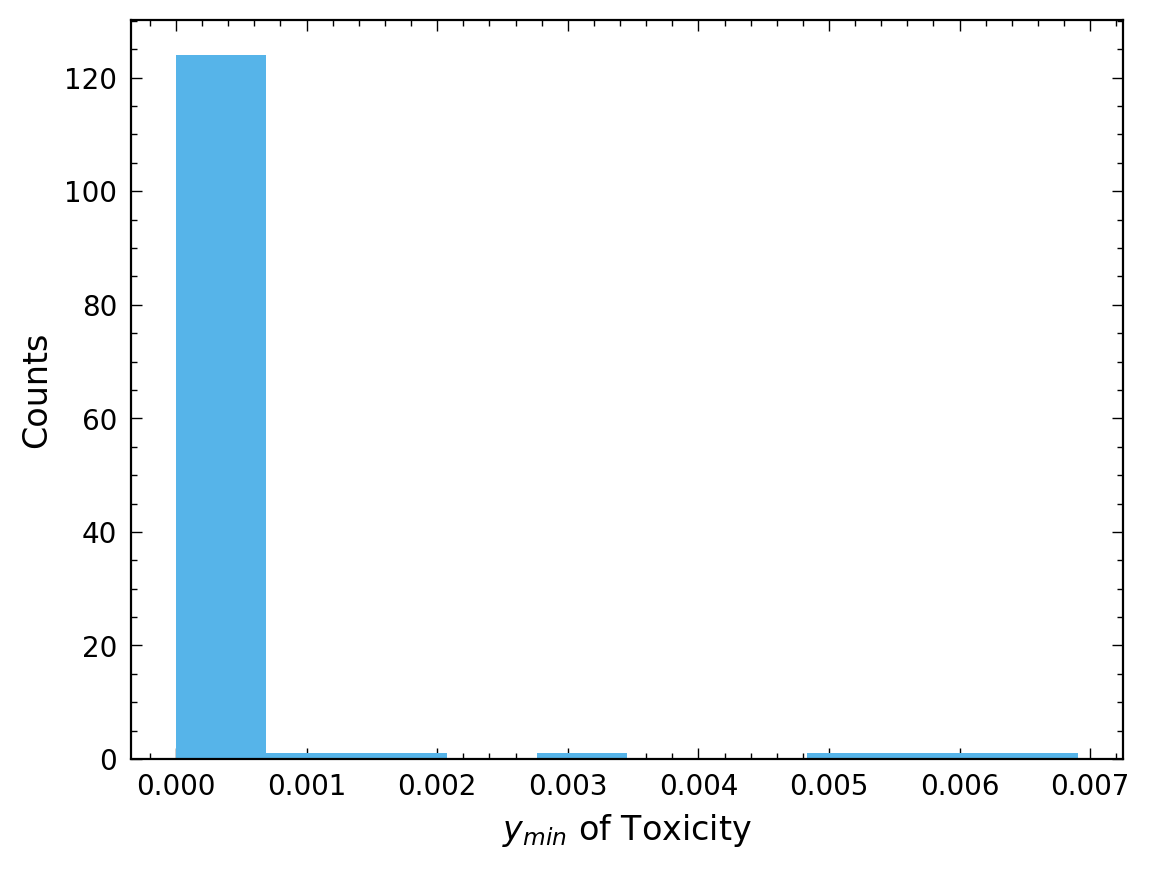

In [14]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

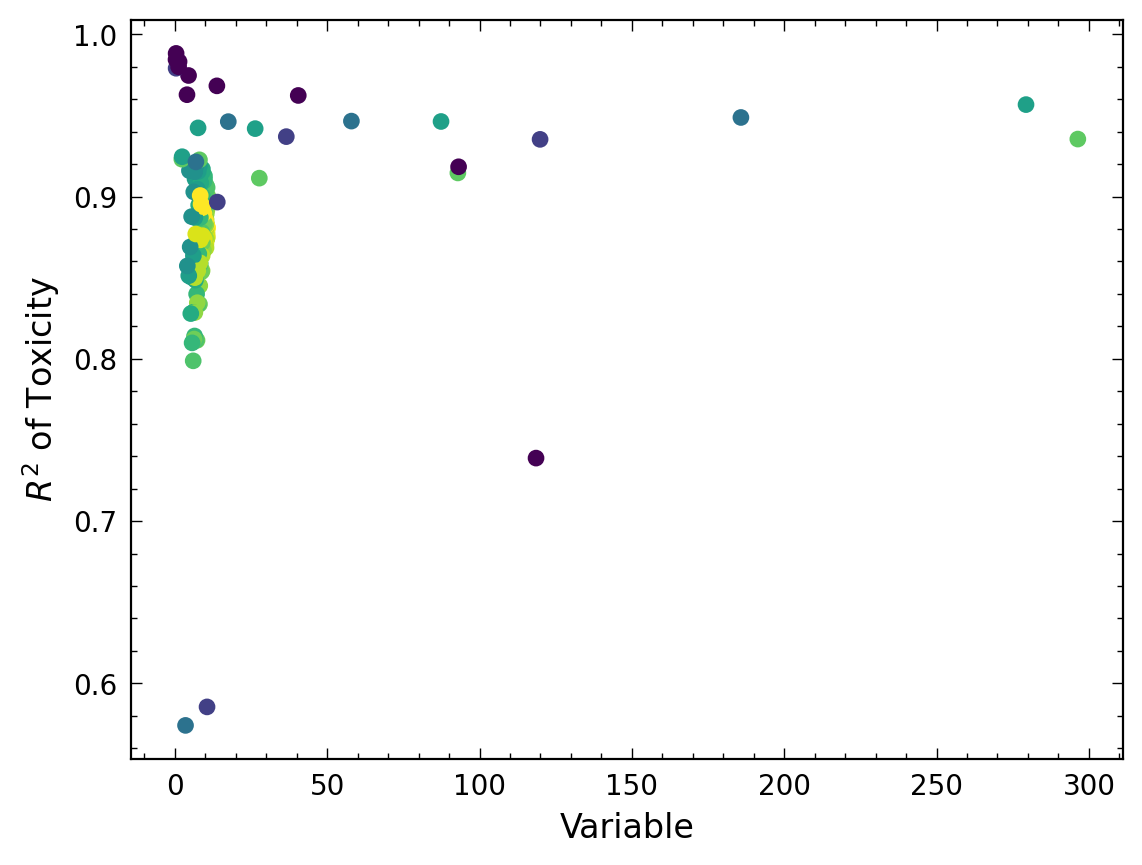

In [15]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)].y_range, model_r_sq, 
            c = 1/impact_data.loc[(impact_data.perf_index == perf)].K_IE, norm=mpl.colors.LogNorm());
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

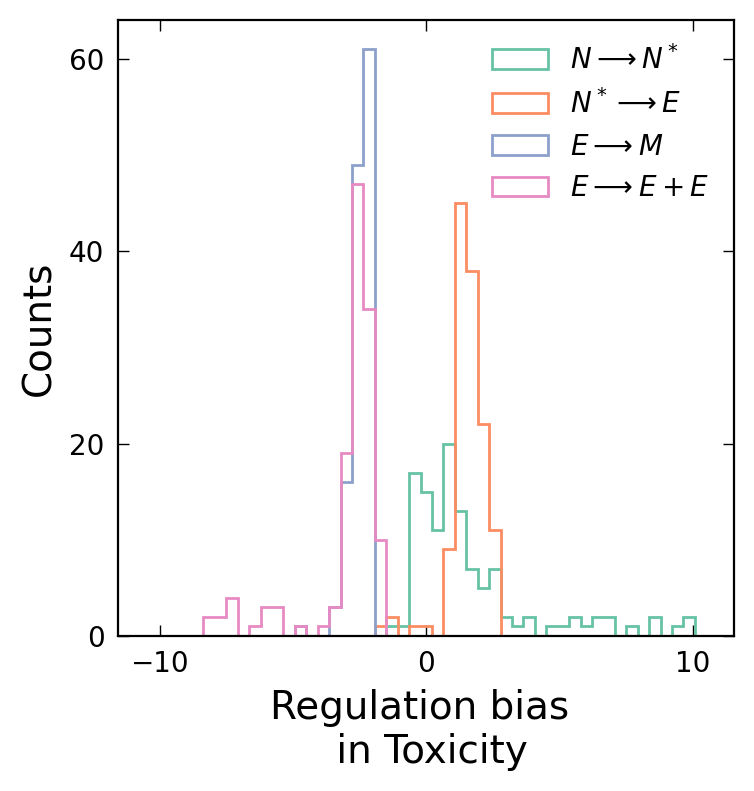

In [16]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

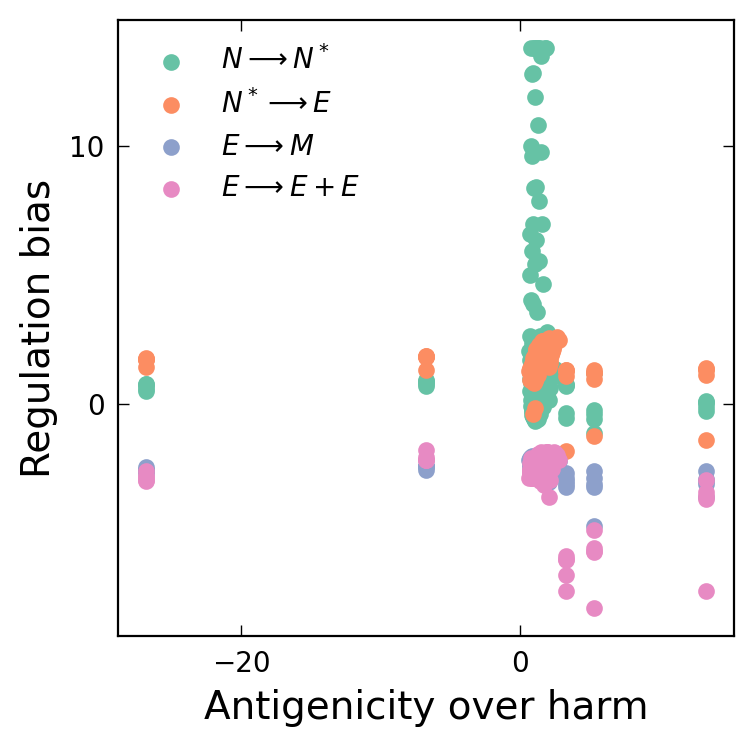

In [17]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

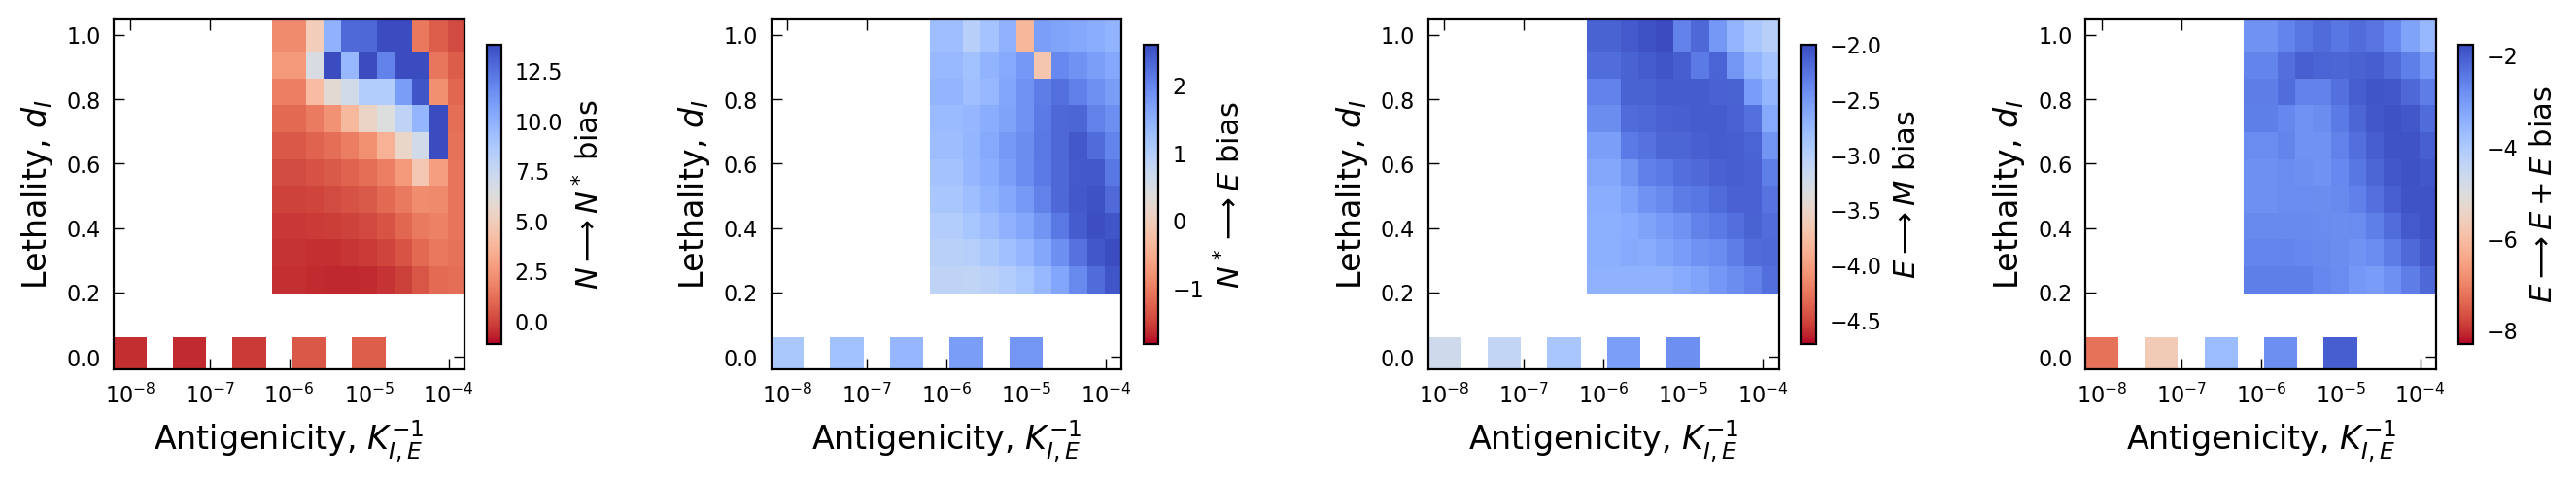

In [18]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

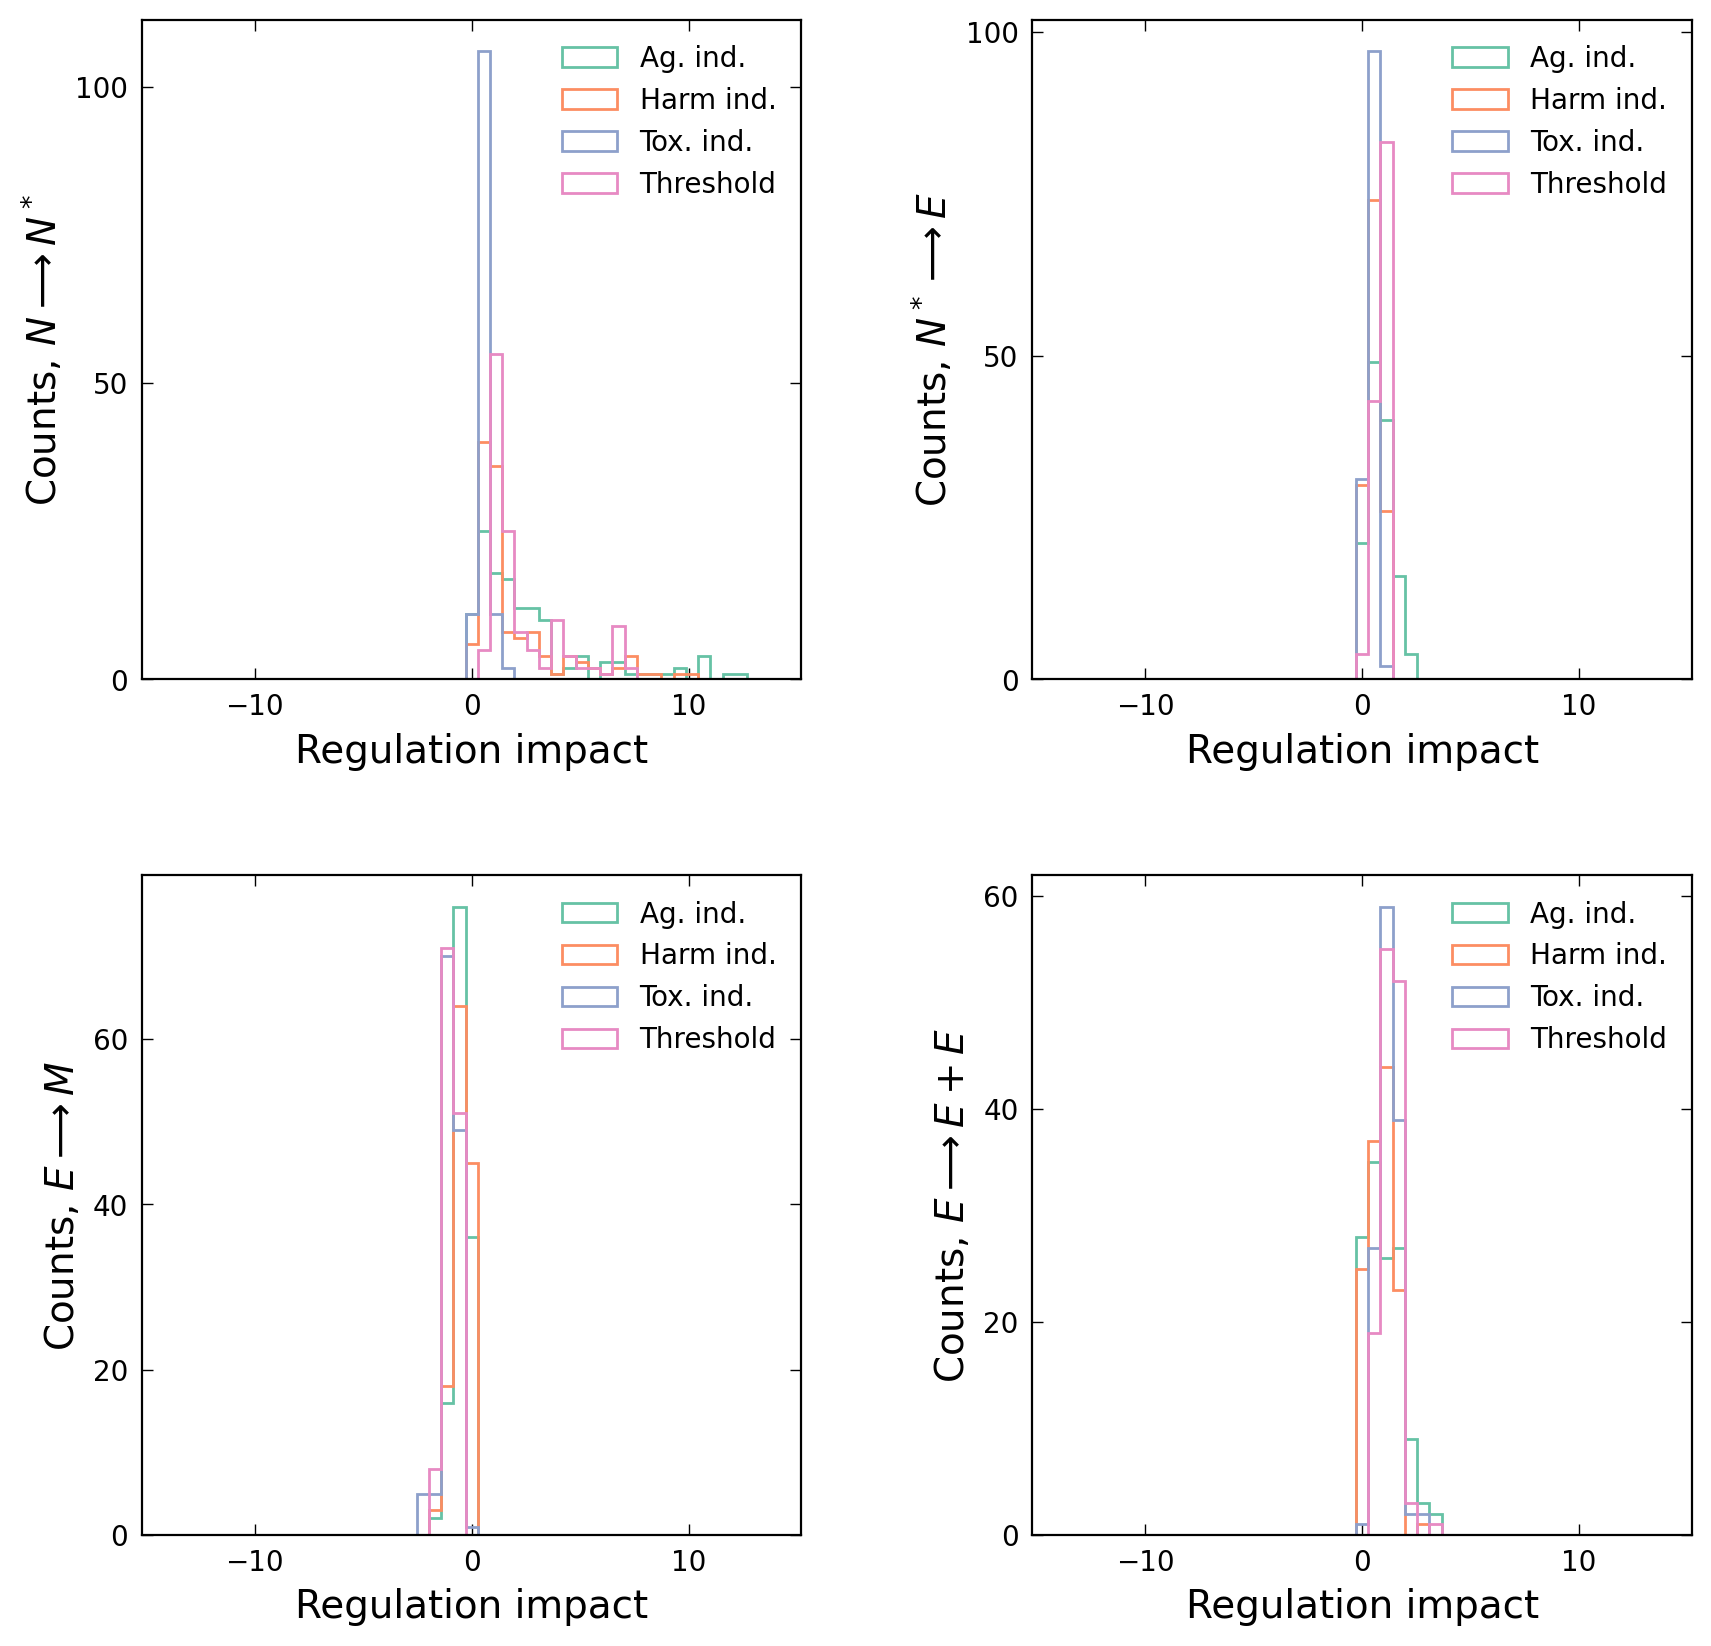

In [19]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*L0_max, 3.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [20]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,L0_Na,psi_NE_I,psi_NE_H,psi_NE_P,L0_NE,psi_EM_I,psi_EM_H,psi_EM_P,L0_EM,psi_EE_I,psi_EE_H,psi_EE_P,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,0.429400,1.665724e-16,0.201838,0.027568,0.296313,4.195388,0.095743,0.164368,0.031312,0.943345,-0.101048,-0.025103,-0.250016,-1.612105,0.144350,0.059880,0.287567,1.865474,2.486703,1.372030,-3.397240,-7.097446,0.000615,0.000009,0.003370,0.003218,0.003403,0.153028,0.001071,0.001081,0.001066,0.001073,0.000888,0.000879,0.000929,0.002935,0.000971,0.000854,0.001421,0.003377,0.005634,0.002430,0.006385,0.008736,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.008683,0.429400,0.0,0.000000e+00,1.0,0.004709,0.043453,0.0,0.094331,0.060789,0.030842,NaN
6,1.399968,1.027746e-04,0.194201,0.157933,0.477478,4.180742,0.087982,0.171330,0.085672,0.938712,-0.118894,-0.026725,-0.561555,-1.430176,0.123018,0.044817,0.611534,1.948740,2.562282,1.382981,-3.054538,-7.579033,0.001417,0.000034,0.003455,0.003400,0.003749,0.120600,0.001274,0.001289,0.001274,0.001286,0.001114,0.001095,0.001441,0.002301,0.000909,0.000893,0.001481,0.002917,0.007243,0.002934,0.004772,0.009612,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.027178,1.394696,0.0,0.000000e+00,1.0,0.017726,0.136732,0.0,0.094329,0.060789,0.062536,NaN
11,4.508140,1.793632e-03,0.196433,0.237627,0.625323,4.153547,0.088976,0.172868,0.158040,0.940578,-0.129893,-0.034312,-0.965639,-1.365245,0.136696,0.051897,0.932983,2.058699,2.590850,1.379258,-3.036591,-8.162621,0.004642,0.000128,0.003780,0.003842,0.004399,0.090817,0.001575,0.001594,0.001590,0.001596,0.001270,0.001247,0.002387,0.002820,0.001128,0.001108,0.001954,0.003438,0.009133,0.003623,0.005855,0.012615,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.083877,4.463505,0.0,0.000000e+00,1.0,0.068016,0.427093,0.0,0.094324,0.060789,0.117081,NaN
16,13.807000,6.140440e-03,0.207642,0.323364,0.806406,3.878283,0.090660,0.179447,0.249523,0.951033,-0.129945,-0.040384,-1.315791,-1.356869,0.161087,0.064938,1.209947,2.085192,2.701858,1.405793,-2.991969,-8.303499,0.014788,0.000446,0.004061,0.004227,0.005143,0.030414,0.001796,0.001820,0.001849,0.001829,0.001495,0.001468,0.003162,0.003032,0.001319,0.001289,0.002556,0.003828,0.011177,0.004140,0.006288,0.014676,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.259380,13.670297,0.0,3.201443e-07,1.0,0.236986,1.330137,0.0,0.094308,0.060789,0.198065,NaN
21,40.515064,6.871128e-04,0.243267,0.407174,1.004273,3.827661,0.087614,0.179549,0.354391,0.930059,-0.101349,-0.038095,-1.701178,-1.397648,0.166532,0.082226,1.446978,1.890489,2.837123,1.392666,-3.025186,-7.363112,0.045687,0.001485,0.004430,0.004715,0.006204,0.020411,0.001959,0.001987,0.002083,0.001949,0.001726,0.001710,0.004799,0.003494,0.001551,0.001519,0.003107,0.003353,0.013431,0.004469,0.007286,0.012299,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.793152,40.113925,0.0,1.076958e-06,1.0,0.786505,4.052520,0.0,0.094260,0.060789,0.310605,NaN


In [21]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,L0_Na,psi_NE_I,psi_NE_H,psi_NE_P,L0_NE,psi_EM_I,psi_EM_H,psi_EM_P,L0_EM,psi_EE_I,psi_EE_H,psi_EE_P,L0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_L0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_L0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
526,2.308768,1.067728e-23,3.084324,0.881899,0.185292,1.173646,1.623357,0.470162,0.092937,0.619640,-1.890992,-0.509930,-0.788179,-1.062275,3.275287,0.963404,0.836014,1.403743,0.935833,1.345532,-2.565156,-1.766262,0.002907,0.000185,0.010396,0.004984,0.004034,0.003400,0.006052,0.003484,0.003077,0.001863,0.005954,0.002674,0.003198,0.003112,0.009107,0.004264,0.004052,0.003438,0.004742,0.006052,0.006242,0.005356,0.01,1.000000e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,0.099527,2.308768,0.0,1.926821e-04,1.0,0.090817,0.327406,2.651569,3.343407,1.141494,0.277244,-6.698971
531,8.089114,1.176456e-37,3.239246,0.917651,0.260248,1.266192,2.135980,0.613710,0.159961,0.860467,-1.410884,-0.374481,-0.933936,-0.940270,3.343156,0.964190,1.312891,1.603146,0.912366,1.867495,-2.391853,-2.165021,0.010398,0.000644,0.011214,0.005185,0.004206,0.003890,0.008194,0.004313,0.003699,0.002812,0.004283,0.002213,0.003201,0.002525,0.009704,0.004420,0.005069,0.004142,0.004708,0.007806,0.004954,0.007104,0.01,1.000000e+05,0.1,50000.0,94.868330,10000000.0,1000000.0,0.332598,8.089114,0.0,6.487652e-04,1.0,0.317915,1.143248,2.651569,3.292048,1.107424,0.423252,-6.698971
536,27.733659,3.520539e-35,3.341951,0.940069,0.330018,1.321142,2.100676,0.598082,0.204370,0.862629,-1.341158,-0.357915,-1.228076,-0.949531,2.884788,0.831311,1.686658,1.565478,0.845556,1.870236,-2.410898,-2.151402,0.037944,0.002370,0.012930,0.005768,0.004684,0.004643,0.008710,0.004612,0.004015,0.003049,0.004480,0.002415,0.004186,0.002762,0.009119,0.004416,0.006208,0.004323,0.004897,0.008451,0.005475,0.007496,0.01,1.000000e+05,0.1,50000.0,300.000000,10000000.0,1000000.0,1.124938,27.733659,0.0,2.098502e-03,1.0,1.172440,3.938237,2.651569,3.225600,1.069916,0.659826,-6.698971
541,92.903055,5.344484e-26,3.462051,0.964832,0.406069,1.384412,2.054814,0.581934,0.257840,0.858921,-1.223068,-0.320914,-1.582074,-0.970725,2.387841,0.690371,2.330341,1.557898,0.777122,1.842478,-2.410462,-2.167744,0.120825,0.007840,0.013842,0.005893,0.004784,0.005151,0.008340,0.004454,0.003954,0.002965,0.004214,0.002419,0.005132,0.002816,0.007743,0.003810,0.007630,0.004254,0.004629,0.008189,0.005603,0.007364,0.01,1.000000e+05,0.1,50000.0,948.683298,10000000.0,1000000.0,3.802498,92.903055,0.0,6.620473e-03,1.0,3.887284,13.300321,2.651569,3.172098,1.022664,1.000762,-6.698971
546,296.369129,3.823809e-36,3.521402,0.968108,0.477792,1.424567,2.000283,0.560665,0.316386,0.851921,-1.011937,-0.244222,-2.149656,-1.053757,1.657047,0.427696,2.886912,1.485465,0.706723,1.814875,-2.427541,-2.044693,0.305555,0.022313,0.012700,0.005189,0.004251,0.004859,0.006944,0.003741,0.003408,0.002507,0.003483,0.002246,0.006093,0.002778,0.005066,0.003193,0.007551,0.003387,0.003833,0.006924,0.005540,0.005824,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,12.739092,296.369129,0.0,2.111569e-02,1.0,11.062932,43.545941,2.651569,3.098727,0.983224,1.364022,-6.698971
551,2.402468,4.253601e-32,1.350025,0.841533,0.180035,1.106863,0.887593,0.555268,0.113518,0.760545,-0.875351,-0.543735,-0.648658,-0.894843,1.918756,1.215882,0.923005,1.658313,0.769098,1.456726,-2.440930,-2.601222,0.003502,0.000164,0.004767,0.003768,0.002966,0.003127,0.003754,0.003160,0.002704,0.002243,0.002850,0.002208,0.002395,0.002315,0.006124,0.004529,0.003940,0.004534,0.004274,0.006239,0.004419,0.008809,0.01,5.623413e+05